In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../reports/charts", exist_ok=True)

In [2]:
nav = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

investor = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

In [3]:
nav['date'] = pd.to_datetime(nav['date'])

investor['transaction_date'] = pd.to_datetime(
    investor['transaction_date']
)

In [4]:
nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = nav.groupby(
    'amfi_code'
)['nav'].pct_change()

In [5]:
var_cvar = []

for code in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==code
    ]['daily_return'].dropna()

    var95 = np.percentile(
        temp,
        5
    )

    cvar95 = temp[
        temp <= var95
    ].mean()

    var_cvar.append(
        [code,var95,cvar95]
    )

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [6]:
var_cvar_df.to_csv(
    "../outputs/var_cvar_report.csv",
    index=False
)

In [7]:
rf = 0.065

top5 = nav[
    'amfi_code'
].unique()[:5]

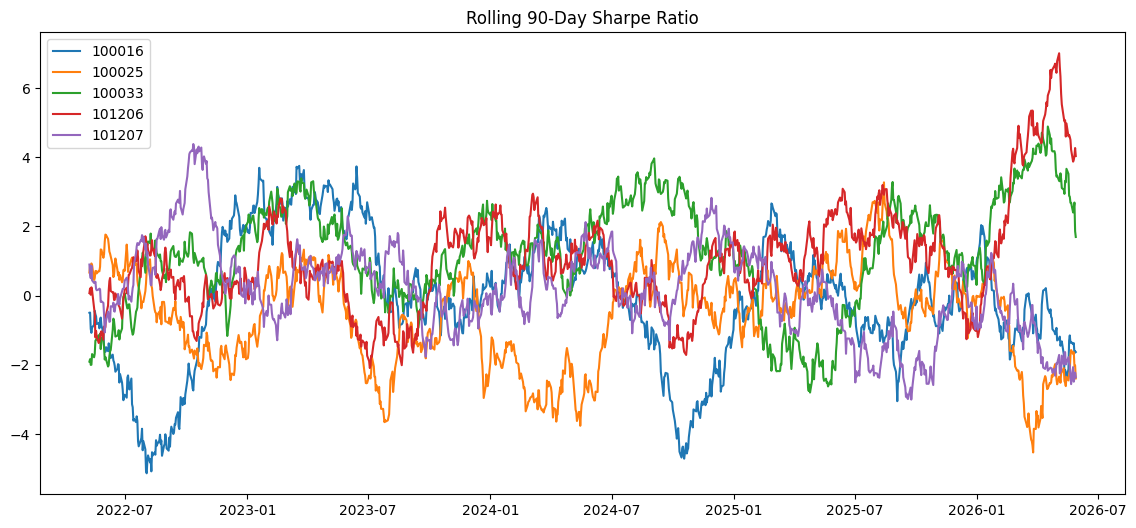

In [8]:
plt.figure(
    figsize=(14,6)
)

for code in top5:

    temp = nav[
        nav['amfi_code']==code
    ].copy()

    rolling_sharpe = (
        (
            temp['daily_return']
            .rolling(90)
            .mean()
            -
            rf/252
        )
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(code)
    )

plt.legend()

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [9]:
cohort = investor.groupby(
    'investor_id'
)['transaction_date'].min()

cohort = cohort.dt.year

investor['cohort_year'] = \
investor['investor_id'].map(
    cohort
)

In [10]:
cohort_summary = investor.groupby(
    'cohort_year'
).agg(
{
'amount_inr':'mean',
'investor_id':'nunique'
}
)

cohort_summary

,amount_inr,investor_id
cohort_year,,
2024,107422.541832,4803
2025,109158.577061,197


In [11]:
sip = investor.copy()

sip = sip.sort_values(
[
'investor_id',
'transaction_date'
]
)

sip['gap_days'] = sip.groupby(
'investor_id'
)[
'transaction_date'
].diff().dt.days

In [12]:
at_risk = sip.groupby(
    'investor_id'
)['gap_days'].mean()

at_risk = at_risk[
    at_risk > 35
]

print(
"At Risk Investors =",
len(at_risk)
)

At Risk Investors = 4305


In [13]:
performance[
[
'amfi_code',
'fund_house',
'risk_grade',
'sharpe_ratio'
]
].head()

,amfi_code,fund_house,risk_grade,sharpe_ratio
0,119551,SBI Mutual Fund,Moderate,0.88
1,119552,SBI Mutual Fund,Moderate,0.81
2,119598,SBI Mutual Fund,Very High,0.94
3,119599,SBI Mutual Fund,Very High,0.93
4,119120,SBI Mutual Fund,Low,1.52


In [14]:
def recommend_funds(
    risk_grade
):

    temp = performance[
        performance[
            'risk_grade'
        ]
        ==
        risk_grade
    ]

    return temp.sort_values(
        'sharpe_ratio',
        ascending=False
    ).head(3)

In [15]:
recommend_funds(
    'High'
)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,0.98,0.90,1.50,19.0,-26.99,37835,1.61,4,High


In [16]:
portfolio['weight'] = \
portfolio['weight_pct']/100

In [17]:
hhi = portfolio.groupby(
    'amfi_code'
)['weight'].apply(
    lambda x:
    np.sum(x**2)
)

hhi = hhi.reset_index()

hhi.columns = [
    'amfi_code',
    'HHI'
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [18]:
print(nav.columns.tolist())
print(investor.columns.tolist())
print(portfolio.columns.tolist())
print(performance.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date', 'weight']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [19]:
hhi.to_csv(
    "../outputs/hhi_report.csv",
    index=False
)

print("HHI Report Saved")

HHI Report Saved


In [20]:
import os

print(os.listdir("../outputs"))
print(os.listdir("../reports/charts"))

['alpha_beta.csv', 'fund_scorecard.csv', 'hhi_report.csv', 'var_cvar_report.csv']
['01_nav_trend.png', '02_aum_growth.png', '03_sip_trend.png', '04_category_heatmap.png', '05_age_distribution.png', '06_gender_distribution.png', '07_state_distribution.png', '08_t30_b30.png', '09_folio_growth.png', '10_correlation_matrix.png', '11_sector_allocation.png', '12_benchmark_trend.png', '13_top10_nav.png', '14_category_distribution.png', '15_risk_distribution.png', '16_rating_distribution.png', '17_transaction_distribution.png', 'benchmark_comparison.png', 'rolling_sharpe_chart.png']


In [ ]:
## Finding 1
Funds with higher returns generally exhibited higher VaR and CVaR values.

## Finding 2
Rolling Sharpe ratios fluctuated significantly during volatile market periods.

## Finding 3
Recent investor cohorts contributed a major share of transaction activity.

## Finding 4
Several investors showed SIP gaps greater than 35 days and were classified as at-risk.

## Finding 5
Funds with higher HHI values had more concentrated portfolios.   




# Advanced Analytics Summary

This notebook implemented advanced risk and investor analytics including VaR, CVaR, Rolling Sharpe Ratio, Investor Cohort Analysis, SIP Continuity Analysis, Fund Recommendation Engine and Portfolio Concentration Analysis using HHI.

The outputs provide additional insights into fund risk characteristics, investor behaviour patterns and portfolio diversification.